In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape

(2640, 12)

In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

1=There are 0 duplicates and 0 null values present in the data means it is clean. No need of any computation regarding handling missing values.

2=Region ,Model and Source_Type are categorical columns.



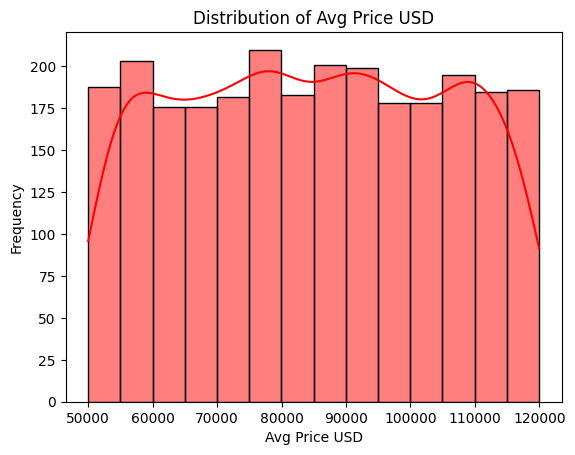

In [9]:
sns.histplot(df['Avg_Price_USD'],kde=True,color='red')
plt.xlabel('Avg Price USD')
plt.ylabel('Frequency')
plt.title('Distribution of Avg Price USD')
plt.show()

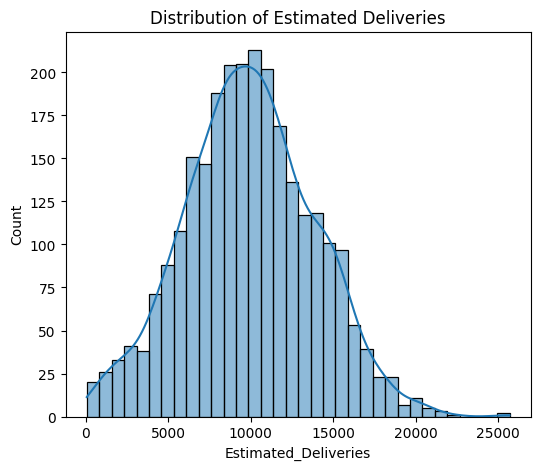

In [12]:
plt.figure(figsize=(6,5))
sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.show()

Text(0.5, 1.0, 'Distribution of Region')

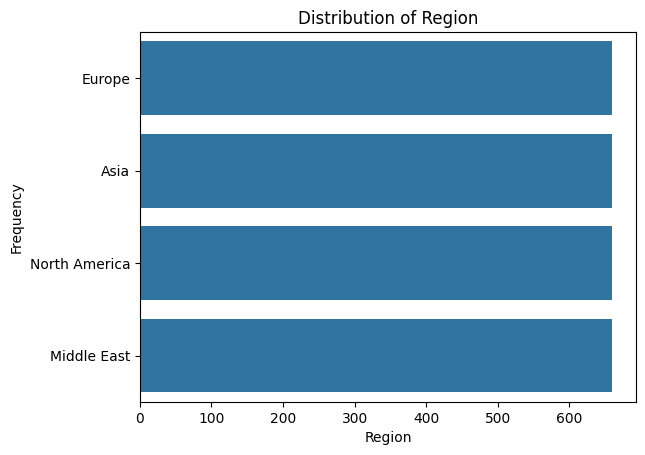

In [ ]:
sns.countplot(df['Region'])
plt.xlabel('Region')
plt.ylabel('Frequency')
plt.title('Distribution of Region')

Text(0.5, 1.0, 'Distribution of Model')

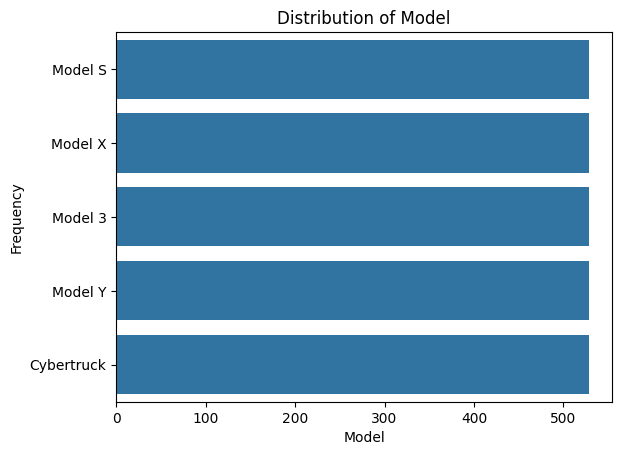

In [ ]:
sns.countplot(df['Model'])
plt.xlabel('Model')
plt.ylabel('Frequency')
plt.title('Distribution of Model')

Text(0.5, 1.0, 'Distribution of Source_Type')

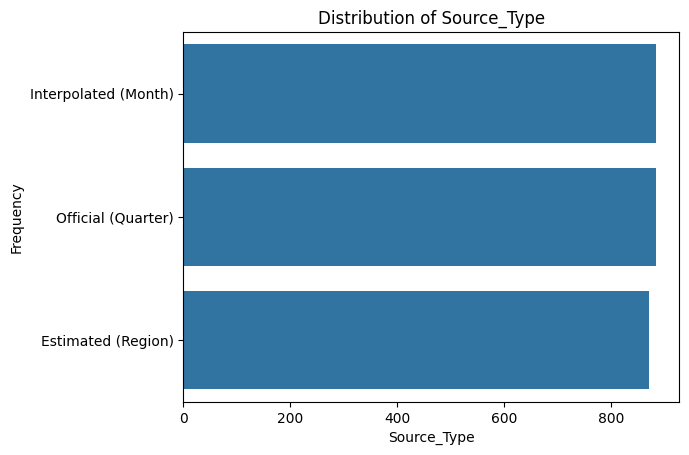

In [ ]:
sns.countplot(df['Source_Type'])
plt.xlabel('Source_Type')
plt.ylabel('Frequency')
plt.title('Distribution of Source_Type')

<Axes: ylabel='count'>

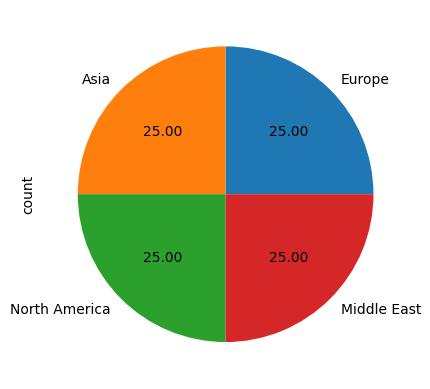

In [ ]:
df['Region'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

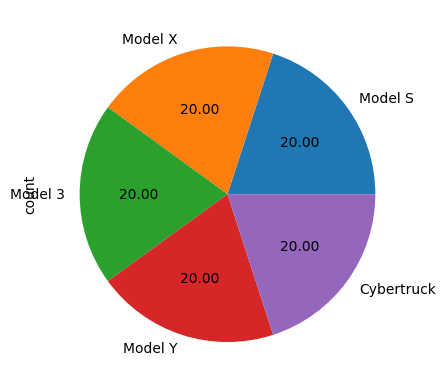

In [ ]:
df['Model'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

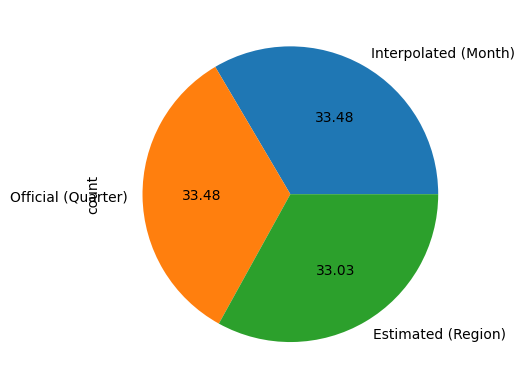

In [ ]:
df['Source_Type'].value_counts().plot(kind='pie',autopct='%.2f')

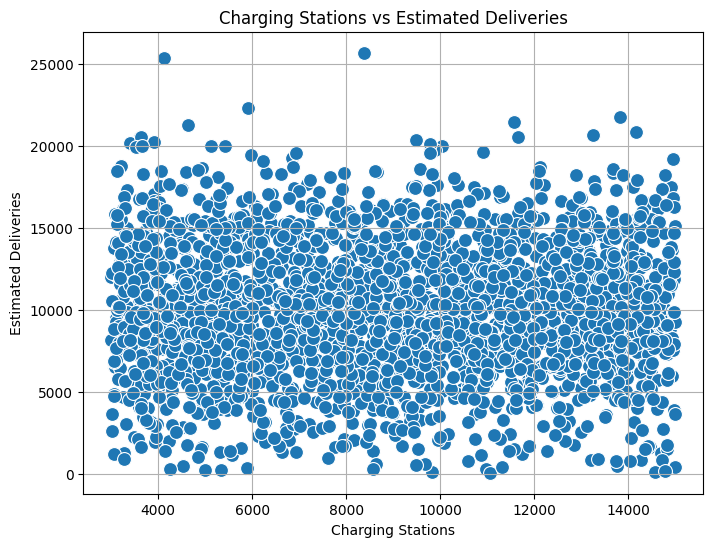

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
data=df,
x='Charging_Stations',
y='Estimated_Deliveries',
s=100
)
plt.title("Charging Stations vs Estimated Deliveries")
plt.xlabel("Charging Stations")
plt.ylabel("Estimated Deliveries")
plt.grid(True)

plt.show()

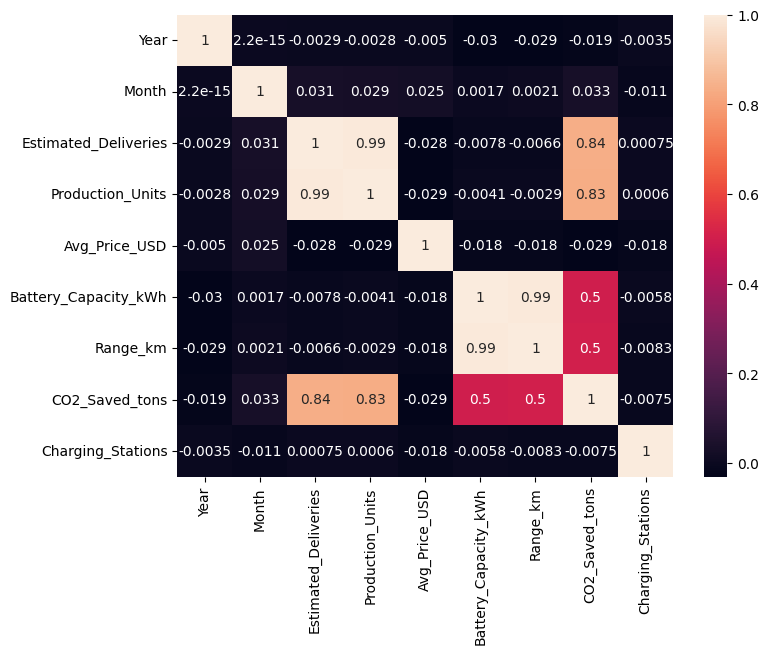

In [15]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

plt.show()

In [16]:


from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX



In [17]:

df["Date"]    = pd.to_datetime(df[["Year", "Month"]].assign(day=1))
df            = df.sort_values("Date").reset_index(drop=True)
df["Quarter"] = df["Date"].dt.quarter
df["Price_per_km"]          = df["Avg_Price_USD"]        / df["Range_km"].clip(lower=1)







In [18]:
le_region = LabelEncoder()
le_model = LabelEncoder()

df["Region_enc"] = le_region.fit_transform(df["Region"])
df["Model_enc"] = le_model.fit_transform(df["Model"])

In [19]:
Q1, Q3 = df["Estimated_Deliveries"].quantile([0.25, 0.75])

IQR = Q3 - Q1
df["Outlier"] = (
      (df["Estimated_Deliveries"] < Q1 - 1.5*IQR) |
      (df["Estimated_Deliveries"] > Q3 + 1.5*IQR)
)
n_outliers = df["Outlier"].sum()

In [20]:
df.shape

(2640, 18)

In [21]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Quarter,Price_per_km,Region_enc,Model_enc
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712,2020-06-16 02:10:54.545454592,2.500000,180.046065,1.500000,2.000000
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000,2015-01-01 00:00:00,1.000000,69.902486,0.000000,0.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000,2017-09-23 12:00:00,1.750000,132.532194,0.750000,1.000000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000,2020-06-16 00:00:00,2.500000,170.357466,1.500000,2.000000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000,2023-03-08 18:00:00,3.250000,219.097320,2.250000,3.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000,2025-12-01 00:00:00,4.000000,359.377801,3.000000,4.000000
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883,NaN,1.118246,61.893503,1.118246,1.414481


In [23]:
y = df['Estimated_Deliveries']
X = df.drop(columns=[
    'Estimated_Deliveries',
    'Region',
    'Model',
    'Source_Type',
    'Date',
    'Outlier'
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression
MAE : 311.9488189636139
MSE : 145262.7570698356
RMSE: 381.13351606731675
R2 Score: 0.9903046687450995


In [26]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("Ridge Regression")
print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("MSE :", mean_squared_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score:", r2_score(y_test, ridge_pred))

Ridge Regression
MAE : 311.9794395412088
MSE : 145279.25577010322
RMSE: 381.15515970547114
R2 Score: 0.9903035675656396


In [27]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

print("Lasso Regression")
print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("MSE :", mean_squared_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2 Score:", r2_score(y_test, lasso_pred))

Lasso Regression
MAE : 311.8707008632833
MSE : 145345.2252223875
RMSE: 381.24168872565275
R2 Score: 0.9902991645396645


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest
MAE : 299.1135227272727
MSE : 149516.9472840909
RMSE: 386.6742133684258
R2 Score: 0.9900207295979943


In [31]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost")
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("MSE :", mean_squared_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2 Score:", r2_score(y_test, xgb_pred))

XGBoost
MAE : 289.7561950683594
MSE : 131111.453125
RMSE: 362.09315531365684
R2 Score: 0.9912492036819458


In [33]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

print(results.sort_values("R2", ascending=False))

           Model        R2
4        XGBoost  0.991249
0         Linear  0.990305
1          Ridge  0.990304
2          Lasso  0.990299
3  Random Forest  0.990021


In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV Scores:", scores)
print("Mean R2:", scores.mean())

CV Scores: [0.98809192 0.99068403 0.98977109 0.98954801 0.98773709]
Mean R2: 0.9891664280298874


In [37]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=params,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 15}
0.9886853325442149


In [39]:
# Sort data by time
df = df.sort_values(["Region", "Model", "Date"])

# Previous month deliveries
df["lag_1"] = (
    df.groupby(["Region", "Model"])["Estimated_Deliveries"]
          .shift(1)
)

# Previous 2 months deliveries
df["lag_2"] = (
    df.groupby(["Region", "Model"])["Estimated_Deliveries"]
          .shift(2)
)

# Rolling average of last 3 months
df["roll_mean_3"] = (
    df.groupby(["Region", "Model"])["Estimated_Deliveries"]
          .transform(lambda x: x.shift(1).rolling(3).mean())
)

# Month seasonality
df["month_sin"] = np.sin(2*np.pi*df["Month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["Month"]/12)

# Remove rows with missing lag values
df = df.dropna()

In [41]:
# Total deliveries per month

ts = (
    df.groupby("Date")["Estimated_Deliveries"]
          .sum()
          .sort_index()
)

ts.index = pd.DatetimeIndex(ts.index, freq="MS")

print(ts.head())

Date
2015-04-01    225623
2015-05-01    184264
2015-06-01    198787
2015-07-01    177759
2015-08-01    214223
Freq: MS, Name: Estimated_Deliveries, dtype: int64


In [42]:
ts_train = ts[ts.index < "2025-01-01"]
ts_test  = ts[ts.index >= "2025-01-01"]

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    ts_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

sarima_forecast = sarima_fit.forecast(len(ts_test))

In [58]:
forecast_df = df.copy()

FEATURES = [
    "lag_1",
    "lag_2",
    "roll_mean_3",
    "month_sin",
    "month_cos"
]

TARGET = "Estimated_Deliveries"

In [49]:
train_df = forecast_df[forecast_df["Year"] < 2025]
test_df  = forecast_df[forecast_df["Year"] == 2025]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

In [52]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)

In [53]:
from sklearn.metrics import mean_absolute_error

print("ETS MAE    :", mean_absolute_error(ts_test, ets_forecast))
print("SARIMA MAE :", mean_absolute_error(ts_test, sarima_forecast))

ETS MAE    : 10732.938910637831
SARIMA MAE : 14054.78220981729


In [55]:
print("XGBoost MAE:", mean_absolute_error(y_test, xgb_forecast))

XGBoost MAE: 2992.089599609375


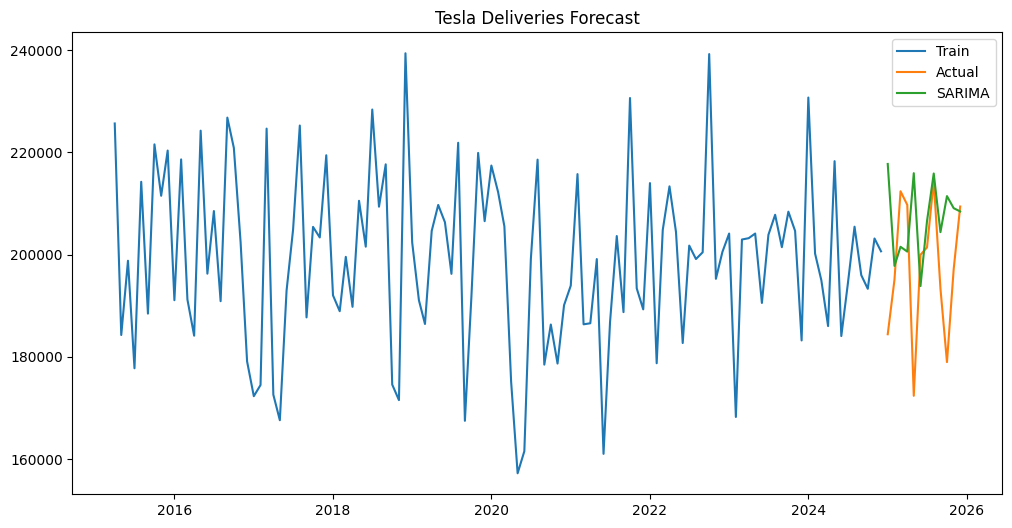

In [59]:
plt.figure(figsize=(12,6))

plt.plot(ts_train.index, ts_train, label="Train")
plt.plot(ts_test.index, ts_test, label="Actual")



plt.plot(ts_test.index, sarima_forecast,
         label="SARIMA")

plt.legend()

plt.title("Tesla Deliveries Forecast")
plt.show()